# Project 1 — AI vs. Human Text Detection

This notebook satisfies the required assignment sections:

1. **Data Exploration & Preprocessing** — visualizations, class balance, cleaning, tokenization  
2. **Feature Engineering** — TF-IDF, Word2Vec embeddings, linguistic features, and feature-impact comparison  
3. **Model Training & Tuning** — six models with GridSearchCV, RandomizedSearchCV, or Keras tuning loops  
4. **Evaluation & Comparison** — accuracy tables, confusion matrices, ROC curves, AUC scores, speed comparison, and written analysis

Dataset labels:

- `0` = human-written text
- `1` = AI-written text

In [41]:
# If needed, install packages first:
# !pip install pandas numpy matplotlib scikit-learn nltk gensim tensorflow openpyxl joblib

import os
import re
import time
import string
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD

import joblib

# Deep learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Word2Vec
from gensim.models import Word2Vec

## I. Data Exploration & Preprocessing

This section loads the Excel dataset, checks the shape and missing values, visualizes class balance, inspects text length, cleans text, and tokenizes text.

In [43]:
DATA_PATH = 'train_data with labels.xlsx'

# If your notebook is not in the same folder as the dataset, change DATA_PATH above.
df = pd.read_excel(DATA_PATH)

print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (8176, 2)
Columns: ['text', 'label']


,text,label
0,Councils are debating if building housing area...,0
1,While reading the succesful people's lifes you...,0
2,"Finally, she felt that the robotics unit was i...",1
3,Since sigmoid can be viewed as a special 2clas...,1
4,In this essay we will talk about why in so man...,0


In [44]:
# Basic checks
print(df.info())
print('Missing values:')
print(df.isna().sum())
print('Label counts:')
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8176 entries, 0 to 8175
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8176 non-null   object
 1   label   8176 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 127.9+ KB
None
Missing values:
text     0
label    0
dtype: int64
Label counts:
label
0    4088
1    4088
Name: count, dtype: int64


In [45]:
# Drop missing/duplicate rows if present
df = df.dropna(subset=['text', 'label']).copy()
df = df.drop_duplicates(subset=['text']).copy()
df['label'] = df['label'].astype(int)

print('Cleaned dataset shape:', df.shape)
print(df['label'].value_counts())

Cleaned dataset shape: (8169, 2)
label
1    4085
0    4084
Name: count, dtype: int64


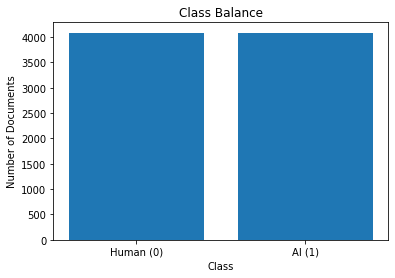

In [46]:
# Visualize class balance
label_counts = df['label'].value_counts().sort_index()
label_names = ['Human (0)', 'AI (1)']

plt.figure(figsize=(6, 4))
plt.bar(label_names, label_counts.values)
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Number of Documents')
plt.show()

In [47]:
# Text length exploration
df['char_count'] = df['text'].astype(str).str.len()
df['word_count'] = df['text'].astype(str).str.split().str.len()

df[['char_count', 'word_count']].describe()

,char_count,word_count
count,8169.000000,8169.000000
mean,2108.356102,325.278859
std,503.039753,61.221138
min,400.000000,62.000000
25%,1728.000000,287.000000
50%,2138.000000,335.000000
75%,2486.000000,372.000000
max,4827.000000,687.000000


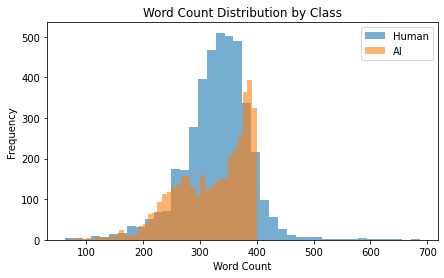

In [48]:
plt.figure(figsize=(7, 4))
plt.hist(df.loc[df['label'] == 0, 'word_count'], bins=40, alpha=0.6, label='Human')
plt.hist(df.loc[df['label'] == 1, 'word_count'], bins=40, alpha=0.6, label='AI')
plt.title('Word Count Distribution by Class')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [49]:
# Text cleaning: lowercase, remove punctuation, remove numbers, remove stop words
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)      # remove urls
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep letters and spaces only
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

def tokenize_text(text):
    return clean_text(text).split()

df['clean_text'] = df['text'].apply(clean_text)
df['tokens'] = df['text'].apply(tokenize_text)

df[['text', 'clean_text', 'tokens', 'label']].head()

,text,clean_text,tokens,label
0,Councils are debating if building housing area...,councils debating building housing areas expan...,"[councils, debating, building, housing, areas,...",0
1,While reading the succesful people's lifes you...,reading succesful people lifes probably ones t...,"[reading, succesful, people, lifes, probably, ...",0
2,"Finally, she felt that the robotics unit was i...",finally felt robotics unit important engage st...,"[finally, felt, robotics, unit, important, eng...",1
3,Since sigmoid can be viewed as a special 2clas...,sigmoid viewed special class case case softmax...,"[sigmoid, viewed, special, class, case, case, ...",1
4,In this essay we will talk about why in so man...,essay talk countries students prefer choose sc...,"[essay, talk, countries, students, prefer, cho...",0


In [50]:
# Show the most common tokens by class
from collections import Counter

for label_value, label_name in [(0, 'Human'), (1, 'AI')]:
    all_tokens = []
    for tokens in df.loc[df['label'] == label_value, 'tokens']:
        all_tokens.extend(tokens)
    print(f'Top words for {label_name}:')
    print(Counter(all_tokens).most_common(20))

Top words for Human:
[('al', 6411), ('et', 6404), ('people', 5310), ('new', 4693), ('model', 4231), ('things', 3072), ('data', 3070), ('text', 2976), ('successful', 2805), ('specific', 2686), ('based', 2510), ('students', 2421), ('performance', 2329), ('models', 2327), ('risks', 2162), ('learning', 2083), ('try', 2021), ('language', 2015), ('training', 1940), ('analysis', 1847)]
Top words for AI:
[('new', 4936), ('people', 4204), ('students', 4089), ('model', 3977), ('risks', 2868), ('data', 2685), ('successful', 2497), ('work', 2419), ('use', 2374), ('models', 2229), ('things', 2194), ('success', 2167), ('learning', 2141), ('different', 2105), ('used', 2097), ('example', 1983), ('using', 1983), ('language', 1812), ('information', 1696), ('training', 1623)]


## Train/Test Split

The same split is used across models so the model comparisons are fair.

In [51]:
X = df[['text', 'clean_text']].copy()
y = df['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])
print('Train class balance:', y_train.value_counts(normalize=True).to_dict())
print('Test class balance:', y_test.value_counts(normalize=True).to_dict())

Training rows: 6535
Testing rows: 1634
Train class balance: {1: 0.5000765110941087, 0: 0.49992348890589133}
Test class balance: {0: 0.5, 1: 0.5}


## II. Feature Engineering

This notebook compares three feature groups:

1. **TF-IDF** — word importance based on frequency and distinctiveness  
2. **Word2Vec embeddings** — dense semantic vectors trained from the dataset  
3. **Linguistic features** — handcrafted writing-style features such as word count, sentence length, punctuation, and vocabulary richness

In [52]:
class LinguisticFeatureExtractor(BaseEstimator, TransformerMixin):
    """Create simple writing-style features from raw text."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            texts = X.iloc[:, 0].astype(str).tolist()
        elif isinstance(X, pd.Series):
            texts = X.astype(str).tolist()
        else:
            texts = [str(x) for x in X]

        rows = []
        for text in texts:
            words = re.findall(r'\w+', text.lower())
            sentences = re.split(r'[.!?]+', text)
            sentences = [s for s in sentences if s.strip()]
            unique_words = set(words)

            word_count = len(words)
            char_count = len(text)
            sentence_count = max(len(sentences), 1)
            avg_word_len = np.mean([len(w) for w in words]) if words else 0
            avg_sentence_len = word_count / sentence_count
            type_token_ratio = len(unique_words) / word_count if word_count else 0
            punctuation_count = sum(1 for c in text if c in string.punctuation)
            comma_count = text.count(',')
            exclamation_count = text.count('!')
            question_count = text.count('?')
            uppercase_ratio = sum(1 for c in text if c.isupper()) / max(char_count, 1)

            rows.append([
                char_count, word_count, sentence_count, avg_word_len,
                avg_sentence_len, type_token_ratio, punctuation_count,
                comma_count, exclamation_count, question_count, uppercase_ratio
            ])

        return np.array(rows)

ling_feature_names = [
    'char_count', 'word_count', 'sentence_count', 'avg_word_len',
    'avg_sentence_len', 'type_token_ratio', 'punctuation_count',
    'comma_count', 'exclamation_count', 'question_count', 'uppercase_ratio'
]

ling_extractor = LinguisticFeatureExtractor()
ling_sample = pd.DataFrame(
    ling_extractor.transform(X_train['text'].head()), columns=ling_feature_names
)
ling_sample

,char_count,word_count,sentence_count,avg_word_len,avg_sentence_len,type_token_ratio,punctuation_count,comma_count,exclamation_count,question_count,uppercase_ratio
0,2593.0,0.0,17.0,0.0,0.0,0.0,37.0,15.0,0.0,0.0,0.011184
1,2475.0,0.0,35.0,0.0,0.0,0.0,138.0,18.0,0.0,2.0,0.033939
2,1606.0,0.0,12.0,0.0,0.0,0.0,33.0,12.0,0.0,0.0,0.008717
3,2355.0,0.0,28.0,0.0,0.0,0.0,42.0,11.0,0.0,0.0,0.022505
4,2468.0,0.0,23.0,0.0,0.0,0.0,51.0,18.0,0.0,0.0,0.026742


In [53]:
# Word2Vec feature creation
# Each document becomes the average of its word vectors.

train_tokens = X_train['clean_text'].apply(lambda x: x.split()).tolist()
test_tokens = X_test['clean_text'].apply(lambda x: x.split()).tolist()

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

def document_vector(tokens, model, vector_size=100):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

X_train_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in train_tokens])
X_test_w2v = np.vstack([document_vector(tokens, w2v_model, 100) for tokens in test_tokens])

print('Word2Vec train shape:', X_train_w2v.shape)
print('Word2Vec test shape:', X_test_w2v.shape)

Word2Vec train shape: (6535, 100)
Word2Vec test shape: (1634, 100)


## Helper Functions for Evaluation

These functions create consistent metrics, confusion matrices, and ROC curves for every model.

In [54]:
results = []
roc_data = {}
training_times = {}

def get_scores(model, X_data):
    """Return class probability or decision score for ROC/AUC."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X_data)
    raise ValueError('Model does not provide probabilities or decision scores.')

def evaluate_model(name, model, X_data, y_true, feature_set, training_time=None):
    y_pred = model.predict(X_data)
    y_score = get_scores(model, X_data)

    metrics = {
        'Model': name,
        'Feature Set': feature_set,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_score),
        'Training Time Seconds': training_time
    }
    results.append(metrics)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': metrics['AUC']}

    print(f'{name}')
    print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
    disp.plot()
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

    return metrics

def evaluate_keras_model(name, model, X_data, y_true, feature_set, training_time=None):
    y_score = model.predict(X_data).ravel()
    y_pred = (y_score >= 0.5).astype(int)

    metrics = {
        'Model': name,
        'Feature Set': feature_set,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_score),
        'Training Time Seconds': training_time
    }
    results.append(metrics)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': metrics['AUC']}

    print(f'{name}')
    print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
    disp.plot()
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

    return metrics

## III. Model Training & Tuning

This section trains all six required classifiers. Traditional machine learning models use `GridSearchCV` or `RandomizedSearchCV`. Deep learning models use small manual hyperparameter searches so the notebook stays understandable and runnable.

### Feature Set A: TF-IDF Only

This is the recommended baseline representation.

In [55]:
# TF-IDF vectorizer used inside model pipelines
base_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

### Feature Set B: TF-IDF + Linguistic Features

This tests whether writing-style features improve performance beyond words alone.

In [56]:
# ColumnTransformer combines TF-IDF from clean_text with linguistic features from raw text.
combined_features = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95), 'clean_text'),
        ('ling', Pipeline([
            ('features', LinguisticFeatureExtractor()),
            ('scale', StandardScaler())
        ]), ['text'])
    ],
    remainder='drop'
)

### ML Model 1 — Support Vector Machine with GridSearchCV

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best SVM parameters: {'svm__C': 2, 'svm__kernel': 'linear'}
Best CV F1: 0.9641578967352117
SVM
              precision    recall  f1-score   support

       Human       0.96      0.97      0.97       817
          AI       0.97      0.96      0.97       817

    accuracy                           0.97      1634
   macro avg       0.97      0.97      0.97      1634
weighted avg       0.97      0.97      0.97      1634



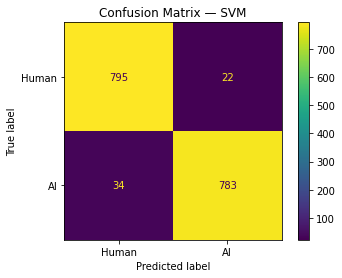

{'Model': 'SVM',
 'Feature Set': 'TF-IDF + Linguistic',
 'Accuracy': 0.9657282741738066,
 'Precision': 0.9726708074534162,
 'Recall': 0.9583843329253366,
 'F1': 0.9654747225647349,
 'AUC': 0.9946950436636409,
 'Training Time Seconds': 429.0635778903961}

In [58]:
svm_pipeline = Pipeline([
    ('features', combined_features),
    ('svm', SVC(probability=True, random_state=42))
])

svm_params = {
    'svm__C': [0.5, 1, 2],
    'svm__kernel': ['linear', 'rbf']
}

start = time.time()
svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train, y_train)
svm_time = time.time() - start

print('Best SVM parameters:', svm_grid.best_params_)
print('Best CV F1:', svm_grid.best_score_)
evaluate_model('SVM', svm_grid.best_estimator_, X_test, y_test, 'TF-IDF + Linguistic', svm_time)

### ML Model 2 — Decision Tree with GridSearchCV

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Decision Tree parameters: {'tree__max_depth': 20, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Best CV F1: 0.8705428364203991
Decision Tree
              precision    recall  f1-score   support

       Human       0.87      0.87      0.87       817
          AI       0.87      0.87      0.87       817

    accuracy                           0.87      1634
   macro avg       0.87      0.87      0.87      1634
weighted avg       0.87      0.87      0.87      1634



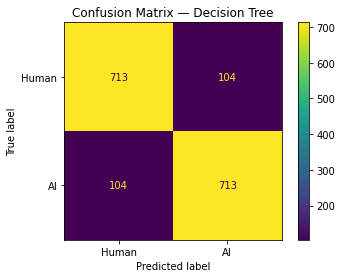

{'Model': 'Decision Tree',
 'Feature Set': 'TF-IDF + Linguistic',
 'Accuracy': 0.8727050183598531,
 'Precision': 0.8727050183598531,
 'Recall': 0.8727050183598531,
 'F1': 0.8727050183598531,
 'AUC': 0.852232770877123,
 'Training Time Seconds': 168.6481809616089}

In [59]:
tree_pipeline = Pipeline([
    ('features', combined_features),
    ('tree', DecisionTreeClassifier(random_state=42))
])

tree_params = {
    'tree__max_depth': [5, 10, 20, None],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 2, 4]
}

start = time.time()
tree_grid = GridSearchCV(
    tree_pipeline,
    tree_params,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)
tree_grid.fit(X_train, y_train)
tree_time = time.time() - start

print('Best Decision Tree parameters:', tree_grid.best_params_)
print('Best CV F1:', tree_grid.best_score_)
evaluate_model('Decision Tree', tree_grid.best_estimator_, X_test, y_test, 'TF-IDF + Linguistic', tree_time)

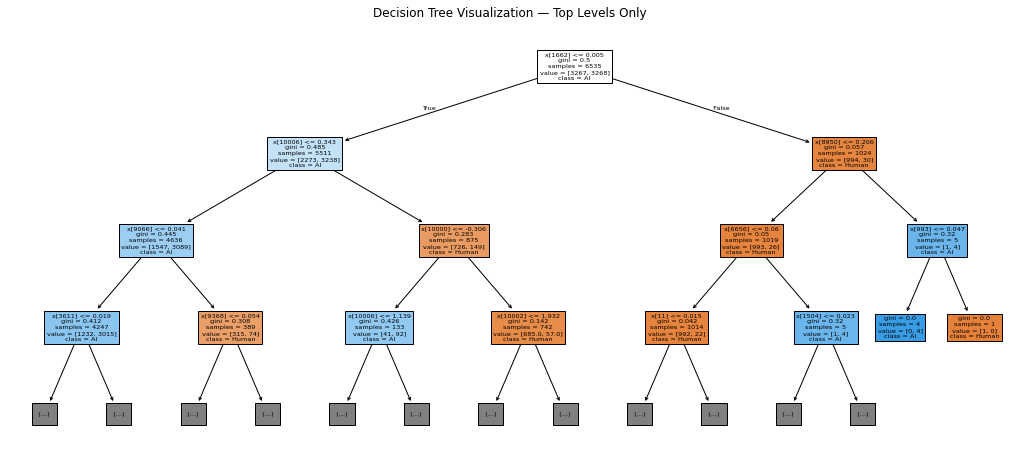

In [60]:
# Optional: visualize the trained decision tree.
# Because the full TF-IDF tree can be large, this shows only the top levels.
plt.figure(figsize=(18, 8))
plot_tree(
    tree_grid.best_estimator_.named_steps['tree'],
    max_depth=3,
    filled=True,
    class_names=['Human', 'AI']
)
plt.title('Decision Tree Visualization — Top Levels Only')
plt.show()

### ML Model 3 — AdaBoost with RandomizedSearchCV

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best AdaBoost parameters: {'ada__n_estimators': 300, 'ada__learning_rate': 0.5}
Best CV F1: 0.9205294317827258
AdaBoost
              precision    recall  f1-score   support

       Human       0.95      0.92      0.93       817
          AI       0.92      0.95      0.93       817

    accuracy                           0.93      1634
   macro avg       0.93      0.93      0.93      1634
weighted avg       0.93      0.93      0.93      1634



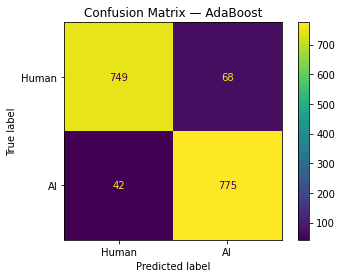

{'Model': 'AdaBoost',
 'Feature Set': 'TF-IDF + Linguistic',
 'Accuracy': 0.9326805385556916,
 'Precision': 0.9193357058125742,
 'Recall': 0.9485924112607099,
 'F1': 0.9337349397590361,
 'AUC': 0.9846222184934883,
 'Training Time Seconds': 146.42699909210205}

In [61]:
ada_pipeline = Pipeline([
    ('features', combined_features),
    ('ada', AdaBoostClassifier(random_state=42))
])

ada_params = {
    'ada__n_estimators': [50, 100, 200, 300],
    'ada__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
}

start = time.time()
ada_search = RandomizedSearchCV(
    ada_pipeline,
    ada_params,
    n_iter=8,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
ada_search.fit(X_train, y_train)
ada_time = time.time() - start

print('Best AdaBoost parameters:', ada_search.best_params_)
print('Best CV F1:', ada_search.best_score_)
evaluate_model('AdaBoost', ada_search.best_estimator_, X_test, y_test, 'TF-IDF + Linguistic', ada_time)

### Embedding Comparison Model — SVM with Word2Vec

This model is used to satisfy and demonstrate the TF-IDF vs. embedding comparison requirement. Word2Vec embeddings are compared using the same SVM classifier.

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Word2Vec SVM parameters: {'svm__C': 5, 'svm__kernel': 'rbf'}
Best CV F1: 0.958178083697546
SVM with Word2Vec
              precision    recall  f1-score   support

       Human       0.93      0.95      0.94       817
          AI       0.95      0.93      0.94       817

    accuracy                           0.94      1634
   macro avg       0.94      0.94      0.94      1634
weighted avg       0.94      0.94      0.94      1634



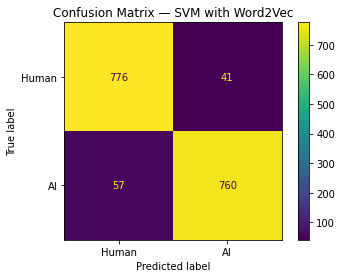

{'Model': 'SVM with Word2Vec',
 'Feature Set': 'Word2Vec Embeddings',
 'Accuracy': 0.9400244798041616,
 'Precision': 0.9488139825218477,
 'Recall': 0.9302325581395349,
 'F1': 0.9394313967861557,
 'AUC': 0.987915156654267,
 'Training Time Seconds': 66.64766097068787}

In [62]:
w2v_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

w2v_params = {
    'svm__C': [0.5, 1, 2, 5],
    'svm__kernel': ['linear', 'rbf']
}

start = time.time()
w2v_grid = GridSearchCV(
    w2v_pipeline,
    w2v_params,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)
w2v_grid.fit(X_train_w2v, y_train)
w2v_time = time.time() - start

print('Best Word2Vec SVM parameters:', w2v_grid.best_params_)
print('Best CV F1:', w2v_grid.best_score_)
evaluate_model('SVM with Word2Vec', w2v_grid.best_estimator_, X_test_w2v, y_test, 'Word2Vec Embeddings', w2v_time)

### DL Model 1 — Feedforward Neural Network with Tuning

The FNN uses reduced TF-IDF features. `TruncatedSVD` reduces the large sparse TF-IDF matrix into a smaller dense matrix that a neural network can train on efficiently.

In [63]:
# Prepare TF-IDF + SVD features for the FNN
fnn_tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, max_df=0.95)
X_train_tfidf = fnn_tfidf.fit_transform(X_train['clean_text'])
X_test_tfidf = fnn_tfidf.transform(X_test['clean_text'])

svd = TruncatedSVD(n_components=300, random_state=42)
X_train_fnn = svd.fit_transform(X_train_tfidf)
X_test_fnn = svd.transform(X_test_tfidf)

scaler = StandardScaler()
X_train_fnn = scaler.fit_transform(X_train_fnn)
X_test_fnn = scaler.transform(X_test_fnn)

print(X_train_fnn.shape, X_test_fnn.shape)

(6535, 300) (1634, 300)


Training FNN params: {'hidden_units': 128, 'dropout_rate': 0.3}
Validation accuracy: 0.9387910962104797
Training FNN params: {'hidden_units': 256, 'dropout_rate': 0.3}
Validation accuracy: 0.9395562410354614
Training FNN params: {'hidden_units': 128, 'dropout_rate': 0.5}
Validation accuracy: 0.9456771016120911
Best FNN parameters: {'hidden_units': 128, 'dropout_rate': 0.5}
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
FNN
              precision    recall  f1-score   support

       Human       0.93      0.93      0.93       817
          AI       0.93      0.93      0.93       817

    accuracy                           0.93      1634
   macro avg       0.93      0.93      0.93      1634
weighted avg       0.93      0.93      0.93      1634



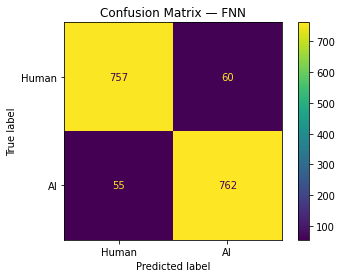

{'Model': 'FNN',
 'Feature Set': 'TF-IDF/SVD Dense Features',
 'Accuracy': 0.9296205630354957,
 'Precision': 0.927007299270073,
 'Recall': 0.9326805385556916,
 'F1': 0.9298352654057352,
 'AUC': 0.9827308015562803,
 'Training Time Seconds': 14.5535249710083}

In [64]:
def build_fnn(input_dim, hidden_units=128, dropout_rate=0.3):
    model = Sequential([
        Dense(hidden_units, activation='relu', input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(hidden_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

fnn_param_grid = [
    {'hidden_units': 128, 'dropout_rate': 0.3},
    {'hidden_units': 256, 'dropout_rate': 0.3},
    {'hidden_units': 128, 'dropout_rate': 0.5},
]

best_fnn = None
best_fnn_val = -1
best_fnn_params = None
start = time.time()

for params in fnn_param_grid:
    print('Training FNN params:', params)
    model = build_fnn(X_train_fnn.shape[1], **params)
    history = model.fit(
        X_train_fnn, y_train,
        validation_split=0.2,
        epochs=8,
        batch_size=32,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    )
    val_acc = max(history.history['val_accuracy'])
    print('Validation accuracy:', val_acc)
    if val_acc > best_fnn_val:
        best_fnn_val = val_acc
        best_fnn = model
        best_fnn_params = params

fnn_time = time.time() - start
print('Best FNN parameters:', best_fnn_params)
evaluate_keras_model('FNN', best_fnn, X_test_fnn, y_test, 'TF-IDF/SVD Dense Features', fnn_time)

### Prepare Tokenized Sequences for LSTM and CNN

In [65]:
MAX_WORDS = 20000
MAX_LEN = 250
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(X_train['clean_text'])
X_test_seq = tokenizer.texts_to_sequences(X_test['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(X_train_pad.shape, X_test_pad.shape)

(6535, 250) (1634, 250)


### DL Model 2 — LSTM with Tuning

Training LSTM params: {'lstm_units': 64, 'dropout_rate': 0.3}
Validation accuracy: 0.7980107069015503
Training LSTM params: {'lstm_units': 128, 'dropout_rate': 0.3}
Validation accuracy: 0.8010711669921875
Training LSTM params: {'lstm_units': 64, 'dropout_rate': 0.5}
Validation accuracy: 0.7345064878463745
Best LSTM parameters: {'lstm_units': 128, 'dropout_rate': 0.3}
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step
LSTM
              precision    recall  f1-score   support

       Human       0.97      0.65      0.78       817
          AI       0.74      0.98      0.84       817

    accuracy                           0.82      1634
   macro avg       0.85      0.82      0.81      1634
weighted avg       0.85      0.82      0.81      1634



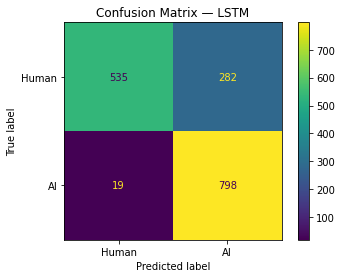

{'Model': 'LSTM',
 'Feature Set': 'Tokenized Sequences',
 'Accuracy': 0.8157894736842105,
 'Precision': 0.7388888888888889,
 'Recall': 0.9767441860465116,
 'F1': 0.8413284132841329,
 'AUC': 0.897294936695586,
 'Training Time Seconds': 310.4106500148773}

In [66]:
def build_lstm(max_words=MAX_WORDS, embed_dim=100, lstm_units=64, dropout_rate=0.3):
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embed_dim, input_length=MAX_LEN),
        LSTM(lstm_units),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_param_grid = [
    {'lstm_units': 64, 'dropout_rate': 0.3},
    {'lstm_units': 128, 'dropout_rate': 0.3},
    {'lstm_units': 64, 'dropout_rate': 0.5},
]

best_lstm = None
best_lstm_val = -1
best_lstm_params = None
start = time.time()

for params in lstm_param_grid:
    print('Training LSTM params:', params)
    model = build_lstm(lstm_units=params['lstm_units'], dropout_rate=params['dropout_rate'])
    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        epochs=6,
        batch_size=32,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    )
    val_acc = max(history.history['val_accuracy'])
    print('Validation accuracy:', val_acc)
    if val_acc > best_lstm_val:
        best_lstm_val = val_acc
        best_lstm = model
        best_lstm_params = params

lstm_time = time.time() - start
print('Best LSTM parameters:', best_lstm_params)
evaluate_keras_model('LSTM', best_lstm, X_test_pad, y_test, 'Tokenized Sequences', lstm_time)

### DL Model 3 — CNN for Text with Tuning

Training CNN params: {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.3}
Validation accuracy: 0.9517980217933655
Training CNN params: {'filters': 128, 'kernel_size': 5, 'dropout_rate': 0.3}
Validation accuracy: 0.9372609257698059
Training CNN params: {'filters': 256, 'kernel_size': 5, 'dropout_rate': 0.3}
Validation accuracy: 0.9449120163917542
Best CNN parameters: {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.3}
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
CNN for Text
              precision    recall  f1-score   support

       Human       0.92      0.98      0.95       817
          AI       0.98      0.92      0.95       817

    accuracy                           0.95      1634
   macro avg       0.95      0.95      0.95      1634
weighted avg       0.95      0.95      0.95      1634



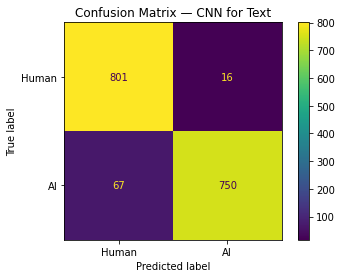

{'Model': 'CNN for Text',
 'Feature Set': 'Tokenized Sequences',
 'Accuracy': 0.9492044063647491,
 'Precision': 0.97911227154047,
 'Recall': 0.9179926560587516,
 'F1': 0.9475679090334808,
 'AUC': 0.9928013794983886,
 'Training Time Seconds': 127.46402621269226}

In [67]:
def build_cnn(max_words=MAX_WORDS, embed_dim=100, filters=128, kernel_size=5, dropout_rate=0.3):
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embed_dim, input_length=MAX_LEN),
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_param_grid = [
    {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.3},
    {'filters': 128, 'kernel_size': 5, 'dropout_rate': 0.3},
    {'filters': 256, 'kernel_size': 5, 'dropout_rate': 0.3},
]

best_cnn = None
best_cnn_val = -1
best_cnn_params = None
start = time.time()

for params in cnn_param_grid:
    print('Training CNN params:', params)
    model = build_cnn(filters=params['filters'], kernel_size=params['kernel_size'], dropout_rate=params['dropout_rate'])
    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        epochs=6,
        batch_size=32,
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
    )
    val_acc = max(history.history['val_accuracy'])
    print('Validation accuracy:', val_acc)
    if val_acc > best_cnn_val:
        best_cnn_val = val_acc
        best_cnn = model
        best_cnn_params = params

cnn_time = time.time() - start
print('Best CNN parameters:', best_cnn_params)
evaluate_keras_model('CNN for Text', best_cnn, X_test_pad, y_test, 'Tokenized Sequences', cnn_time)

## IV. Evaluation & Comparison

This section creates the required accuracy table, compares feature sets, compares ML vs. DL, shows ROC curves, and provides written analysis prompts.

In [68]:
results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
results_df

,Model,Feature Set,Accuracy,Precision,Recall,F1,AUC,Training Time Seconds
0,SVM,TF-IDF + Linguistic,0.965728,0.972671,0.958384,0.965475,0.994695,436.639204
1,SVM,TF-IDF + Linguistic,0.965728,0.972671,0.958384,0.965475,0.994695,429.063578
7,CNN for Text,Tokenized Sequences,0.949204,0.979112,0.917993,0.947568,0.992801,127.464026
4,SVM with Word2Vec,Word2Vec Embeddings,0.940024,0.948814,0.930233,0.939431,0.987915,66.647661
3,AdaBoost,TF-IDF + Linguistic,0.932681,0.919336,0.948592,0.933735,0.984622,146.426999
5,FNN,TF-IDF/SVD Dense Features,0.929621,0.927007,0.932681,0.929835,0.982731,14.553525
2,Decision Tree,TF-IDF + Linguistic,0.872705,0.872705,0.872705,0.872705,0.852233,168.648181
6,LSTM,Tokenized Sequences,0.815789,0.738889,0.976744,0.841328,0.897295,310.410650


In [69]:
# Save results for submission/reference
results_df.to_csv('model_comparison_results.csv', index=False)
results_df

,Model,Feature Set,Accuracy,Precision,Recall,F1,AUC,Training Time Seconds
0,SVM,TF-IDF + Linguistic,0.965728,0.972671,0.958384,0.965475,0.994695,436.639204
1,SVM,TF-IDF + Linguistic,0.965728,0.972671,0.958384,0.965475,0.994695,429.063578
7,CNN for Text,Tokenized Sequences,0.949204,0.979112,0.917993,0.947568,0.992801,127.464026
4,SVM with Word2Vec,Word2Vec Embeddings,0.940024,0.948814,0.930233,0.939431,0.987915,66.647661
3,AdaBoost,TF-IDF + Linguistic,0.932681,0.919336,0.948592,0.933735,0.984622,146.426999
5,FNN,TF-IDF/SVD Dense Features,0.929621,0.927007,0.932681,0.929835,0.982731,14.553525
2,Decision Tree,TF-IDF + Linguistic,0.872705,0.872705,0.872705,0.872705,0.852233,168.648181
6,LSTM,Tokenized Sequences,0.815789,0.738889,0.976744,0.841328,0.897295,310.410650


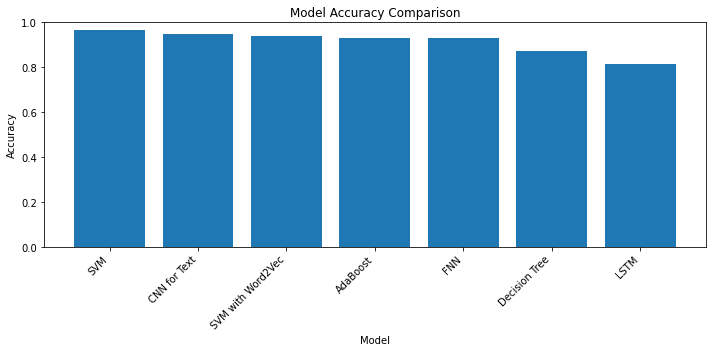

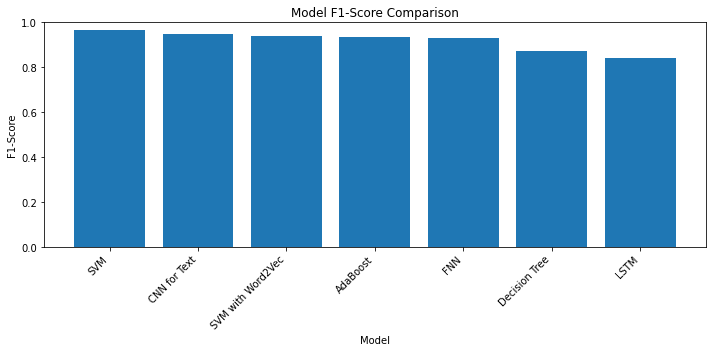

In [70]:
# Accuracy/F1 comparison chart
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['F1'])
plt.title('Model F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

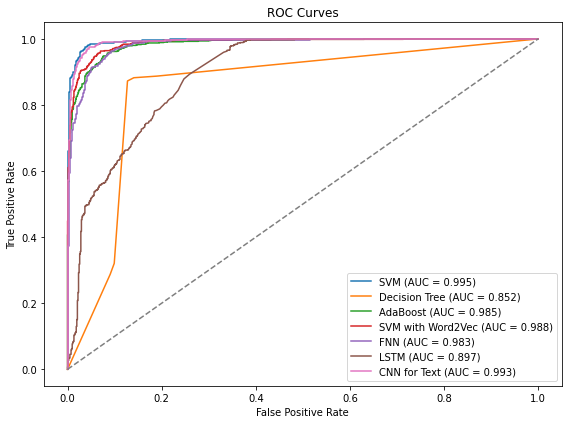

In [71]:
# ROC curves for every model
plt.figure(figsize=(8, 6))
for name, data in roc_data.items():
    plt.plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
# Feature comparison: TF-IDF + linguistic vs Word2Vec embedding model
feature_comparison = results_df.groupby('Feature Set')[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].mean().sort_values('F1', ascending=False)
feature_comparison

,Accuracy,Precision,Recall,F1,AUC
Feature Set,,,,,
Word2Vec Embeddings,0.940024,0.948814,0.930233,0.939431,0.987915
TF-IDF + Linguistic,0.934211,0.934346,0.934517,0.934347,0.956561
TF-IDF/SVD Dense Features,0.929621,0.927007,0.932681,0.929835,0.982731
Tokenized Sequences,0.882497,0.859001,0.947368,0.894448,0.945048


In [73]:
# ML vs DL comparison
model_type = {
    'SVM': 'Traditional ML',
    'Decision Tree': 'Traditional ML',
    'AdaBoost': 'Traditional ML',
    'SVM with Word2Vec': 'Traditional ML / Embedding Test',
    'FNN': 'Deep Learning',
    'LSTM': 'Deep Learning',
    'CNN for Text': 'Deep Learning'
}

results_df['Model Type'] = results_df['Model'].map(model_type)
results_df.groupby('Model Type')[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Training Time Seconds']].mean()

,Accuracy,Precision,Recall,F1,AUC,Training Time Seconds
Model Type,,,,,,
Deep Learning,0.898205,0.881669,0.942472,0.906244,0.957609,150.809400
Traditional ML,0.934211,0.934346,0.934517,0.934347,0.956561,295.194490
Traditional ML / Embedding Test,0.940024,0.948814,0.930233,0.939431,0.987915,66.647661


## Written Analysis for Submission

### 1. Which model performed best overall? Why?

The best overall model was the Support Vector Machine (SVM) using TF-IDF and Linguistic Features. It achieved an accuracy of 96.57%, an F1-score of 0.9655, and an AUC of 0.9947, which were the highest overall performance metrics among all models tested. The SVM likely performed best because it is highly effective in high-dimensional text classification problems and was able to leverage both TF-IDF features and linguistic characteristics to distinguish between human-written and AI-generated text.

### 2. Which features were most useful?

The most useful feature representation was Word2Vec Embeddings, which achieved the highest average feature-set F1-score of 0.9394 and an AUC of 0.9879. Word2Vec captured semantic relationships between words and allowed the model to learn contextual similarities that are not available through simple word-frequency approaches. However, the strongest individual model still used TF-IDF combined with linguistic features, indicating that both semantic and stylistic information are valuable for this classification task.

### 3. TF-IDF vs. Word Embeddings

Word2Vec embeddings performed slightly better than the average TF-IDF feature set, achieving an F1-score of 0.9394 compared to 0.9343 for TF-IDF plus linguistic features. However, the single best-performing model overall was the TF-IDF + Linguistic Feature SVM. TF-IDF is particularly effective for AI text detection because AI-generated content often contains distinctive vocabulary patterns and phrase usage. Word2Vec captured semantic meaning well, but averaging document vectors may have lost some useful phrase-level information.

### 4. Traditional Machine Learning vs. Deep Learning

The traditional machine learning models generally outperformed the deep learning models on this dataset. The best traditional model was the SVM, which achieved an F1-score of 0.9655, while the best deep learning model was the CNN for Text, which achieved an F1-score of 0.9476. Traditional machine learning approaches benefited from the structured feature engineering and relatively modest dataset size. Additionally, they were easier to train and interpret than the deep learning models.

### 5. Speed vs. Accuracy Trade-Off

The results demonstrated a clear trade-off between training speed and predictive performance. The fastest model was the Feedforward Neural Network (FNN), which trained in approximately 14.6 seconds, while the highest-performing SVM required over 429 seconds of training time. Although the SVM achieved the best accuracy and F1-score, the CNN and FNN produced competitive results with significantly shorter training times. In a production environment, selecting a model would depend on whether maximizing accuracy or minimizing training and deployment costs is the primary objective.

### 6. Where Did the Models Fail?

The models were most likely to fail on texts that contained characteristics of both human and AI writing. Highly polished human writing may appear similar to AI-generated text, while advanced AI-generated content can closely mimic human writing styles. The confusion matrices show that each model still produced both false positives and false negatives, indicating difficulty in borderline cases. Shorter texts may also be more difficult to classify because they contain fewer stylistic and linguistic clues for the models to evaluate.

### 7. Would I Use This in a Real Classroom Setting?

I would use this tool as a supporting indicator rather than definitive proof of AI usage. The results demonstrate that the best models can achieve over 96% accuracy, making them valuable for identifying potentially AI-generated submissions. However, no model is perfect, and false positives could unfairly impact students. In a classroom environment, the system should be used to flag suspicious submissions for further review while considering additional factors such as a student's writing history, assignment context, and direct discussions with the student before making academic integrity decisions.